In [2]:
import copy
import datetime as dt
import importlib # needed so that we can reload packages
import matplotlib.pyplot as plt
import os, os.path
import numpy as np
import pandas as pd
import pathlib
import sys
import time
from typing import Union
import warnings
from datetime import datetime
warnings.filterwarnings("ignore")
import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

##  IMPORT SISEPUEDE EXAMPLES AND TRANSFORMERS

from sisepuede.manager.sisepuede_examples import SISEPUEDEExamples
from sisepuede.manager.sisepuede_file_structure import SISEPUEDEFileStructure
import sisepuede.core.support_classes as sc
import sisepuede.transformers as trf
import sisepuede.utilities._plotting as spu
import sisepuede.utilities._toolbox as sf

In [3]:
%load_ext autoreload
%autoreload 2

### Initial Set up

Make sure to edit the config yaml under croatia/config_files/croatia_config.yaml

You can also create a new config yaml



In [4]:
# Set up dir paths

CURR_DIR_PATH = pathlib.Path(os.getcwd())
SSP_MODELING_DIR_PATH = CURR_DIR_PATH.parent
PROJECT_DIR_PATH = SSP_MODELING_DIR_PATH.parent
DATA_DIR_PATH = SSP_MODELING_DIR_PATH.joinpath("input_data")
RUN_OUTPUT_DIR_PATH = SSP_MODELING_DIR_PATH.joinpath("ssp_run_output")
SCENARIO_MAPPING_DIR_PATH = SSP_MODELING_DIR_PATH.joinpath("scenario_mapping")
CONFIG_DIR_PATH = SSP_MODELING_DIR_PATH.joinpath("config_files")
TRANSFORMATIONS_DIR_PATH = SSP_MODELING_DIR_PATH.joinpath("transformations")
MISC_DIR_PATH = SSP_MODELING_DIR_PATH.joinpath("misc")
STRATEGIES_DEFINITIONS_FILE_PATH = TRANSFORMATIONS_DIR_PATH.joinpath("strategy_definitions.csv")
STRATEGY_MAPPING_FILE_PATH = MISC_DIR_PATH.joinpath("strategy_mapping.yaml")

In [5]:
from ssp_transformations_handler.GeneralUtils import GeneralUtils
from ssp_transformations_handler.TransformationUtils import TransformationYamlProcessor, StrategyCSVHandler

# Initialize general utilities
g_utils = GeneralUtils()

In [6]:
# Load config file, double check your parameters are correct

YAML_FILE_PATH = os.path.join(CONFIG_DIR_PATH, "config.yaml")
config_params = g_utils.read_yaml(YAML_FILE_PATH)

country_name = config_params['country_name']
ssp_input_file_name = config_params['ssp_input_file_name']
ssp_transformation_cw = config_params['ssp_transformation_cw']
energy_model_flag = config_params['energy_model_flag']
set_lndu_reallocation_factor_to_zero_flag = config_params['set_lndu_reallocation_factor_to_zero']

# Print config parameters
logging.info(f"Country name: {country_name}")
logging.info(f"SSP input file name: {ssp_input_file_name}")
logging.info(f"SSP transformation CW: {ssp_transformation_cw}")
logging.info(f"Energy model flag: {energy_model_flag}")
logging.info(f"Set lndu reallocation factor to zero flag: {set_lndu_reallocation_factor_to_zero_flag}")

2025-07-18 18:28:06,111 - INFO - Country name: libya
2025-07-18 18:28:06,111 - INFO - SSP input file name: LBY_real_data_20250718.csv
2025-07-18 18:28:06,112 - INFO - SSP transformation CW: None
2025-07-18 18:28:06,112 - INFO - Energy model flag: True
2025-07-18 18:28:06,112 - INFO - Set lndu reallocation factor to zero flag: True


In [7]:
# Set up SSP objects

INPUT_FILE_PATH = DATA_DIR_PATH.joinpath(ssp_input_file_name)

file_struct = SISEPUEDEFileStructure()

matt = file_struct.model_attributes
regions = sc.Regions(matt)
time_periods = sc.TimePeriods(matt)

### Making sure our input file has the correct format and correct columns
We use an example df with the complete fields and correct format to make sure our file is in the right shape

In [8]:
##  BUILD BASE INPUTS
df_inputs_raw = pd.read_csv(INPUT_FILE_PATH)

# pull example data to fill in gaps
examples = SISEPUEDEExamples()
df_inputs_example = examples.input_data_frame

In [9]:
# Double checking that our df is in the correct shape (Empty sets should be printed to make sure everything is Ok!)
g_utils.compare_dfs(df_inputs_example, df_inputs_raw)

Columns in df_example but not in df_input: {'nemomod_entc_input_activity_ratio_fuel_production_fp_ammonia_production_hydrogen', 'nemomod_entc_input_activity_ratio_fuel_production_fp_hydrogen_electrolysis_water', 'nemomod_entc_input_activity_ratio_fuel_production_fp_ammonia_production_electricity', 'region', 'nemomod_entc_input_activity_ratio_fuel_production_fp_hydrogen_reformation_ccs_natural_gas', 'exports_enfu_pj_fuel_ammonia', 'nemomod_entc_output_activity_ratio_fuel_production_fp_ammonia_production_ammonia', 'nemomod_entc_grid_power_constraint_mmm_usd', 'nemomod_entc_emissions_activity_ratio_scalar_fp_hydrogen_reformation_ccs_co2', 'ef_enfu_stationary_combustion_tonne_n2o_per_tj_fuel_ammonia', 'frac_enfu_fuel_demand_imported_pj_fuel_ammonia', 'ef_enfu_combustion_tonne_co2_per_tj_fuel_ammonia', 'nemomod_entc_capital_cost_fp_hydrogen_reformation_ccs_mm_usd_per_gw', 'nemomod_entc_emissions_activity_ratio_fuel_production_fp_hydrogen_reformation_ccs_tonne_co2_per_tj', 'nemomod_entc_outp

In [10]:
# Ensure if time_period field exist
if 'time_period' not in df_inputs_raw.columns:
    logging.info("Adding 'time_period' column to df_inputs_raw")
    df_inputs_raw = df_inputs_raw.rename(columns={'period':'time_period'})
else:
    logging.info("'time_period' column already exists in df_inputs_raw")

2025-07-18 18:28:06,724 - INFO - 'time_period' column already exists in df_inputs_raw


In [11]:
# Fixes differences and makes sure that our df is in the correct format.
# Note: Edit this if you need more changes in your df

df_inputs_raw_complete = g_utils.add_missing_cols(df_inputs_example, df_inputs_raw.copy())
df_inputs_raw_complete = g_utils.remove_additional_cols(df_inputs_example, df_inputs_raw_complete.copy())
df_inputs_raw_complete.head()

,frac_lvst_mm_sheep_anaerobic_lagoon,ef_lndu_conv_other_to_forests_primary_gg_co2_ha,ef_lndu_conv_other_to_forests_mangroves_gg_co2_ha,pij_lndu_other_to_forests_mangroves,frac_lvst_mm_cattle_nondairy_dry_lot,frac_lvst_mm_buffalo_paddock_pasture_range,pij_lndu_settlements_to_settlements,frac_lvst_mm_pigs_anaerobic_lagoon,frac_agrc_nuts_cl1_temperate,pij_lndu_forests_primary_to_forests_mangroves,...,nemomod_entc_input_activity_ratio_fuel_production_fp_hydrogen_electrolysis_water,nemomod_entc_input_activity_ratio_fuel_production_fp_hydrogen_reformation_ccs_electricity,energydensity_gravimetric_enfu_gj_per_tonne_fuel_ammonia,energydensity_gravimetric_enfu_gj_per_tonne_fuel_water,frac_trns_fuelmix_water_borne_ammonia,nemomod_entc_output_activity_ratio_fuel_production_fp_ammonia_production_ammonia,nemomod_entc_output_activity_ratio_fuel_production_fp_hydrogen_reformation_ccs_hydrogen,nemomod_entc_frac_min_share_production_fp_hydrogen_reformation_ccs,nemomod_entc_input_activity_ratio_fuel_production_fp_hydrogen_reformation_ccs_natural_gas,nemomod_entc_input_activity_ratio_fuel_production_fp_hydrogen_reformation_ccs_oil
0,0.0,0.0,0.0,0.0,0.46,0.515,1.0,0.075,1.0,0.492421,...,0.000004,0,18.6,0.00005,0.0,1,1,0.0,1.315,0.0
1,0.0,0.0,0.0,0.0,0.46,0.515,1.0,0.075,1.0,0.492451,...,0.000004,0,18.6,0.00005,0.0,1,1,0.0,1.315,0.0
2,0.0,0.0,0.0,0.0,0.46,0.515,1.0,0.075,1.0,0.492232,...,0.000004,0,18.6,0.00005,0.0,1,1,0.0,1.315,0.0
3,0.0,0.0,0.0,0.0,0.46,0.515,1.0,0.075,1.0,0.492208,...,0.000004,0,18.6,0.00005,0.0,1,1,0.0,1.315,0.0
4,0.0,0.0,0.0,0.0,0.46,0.515,1.0,0.075,1.0,0.492322,...,0.000004,0,18.6,0.00005,0.0,1,1,0.0,1.315,0.0


In [12]:
# Double checking that our df is in the correct shape (Empty sets should be printed to make sure everything is Ok!)
g_utils.compare_dfs(df_inputs_example, df_inputs_raw_complete)

Columns in df_example but not in df_input: set()
Columns in df_input but not in df_example: set()


In [13]:
# Set region to country name
df_inputs_raw_complete['region'] = country_name
df_inputs_raw_complete['region'].head()

0    libya
1    libya
2    libya
3    libya
4    libya
Name: region, dtype: object

## Let's Modify the  LNDU Reallocation factor

In [14]:
if set_lndu_reallocation_factor_to_zero_flag:
    df_inputs_raw_complete['lndu_reallocation_factor'] = 0

df_inputs_raw_complete['lndu_reallocation_factor'].mean()

0.0

#  Let's try building transformations using this


In [15]:
transformers = trf.transformers.Transformers(
    {},
    df_input = df_inputs_raw_complete,
)

##  Instantiate some transformations. Make sure to run this cell to create the transformations folder for the first time or if you wish to overwrite

In [16]:
# set an ouput path and instantiate
if not TRANSFORMATIONS_DIR_PATH.exists():
    trf.instantiate_default_strategy_directory(
        transformers,
        TRANSFORMATIONS_DIR_PATH,
    )
else:
    logging.info(f"Directory {TRANSFORMATIONS_DIR_PATH} already exists. Skipping instantiation.")


2025-07-18 18:28:07,183 - INFO - Directory /Users/fabianfuentes/git/ssp_libya/ssp_modeling/transformations already exists. Skipping instantiation.


##  --HERE, CUSTOMIZE YOUR TRANSFORMATIONS AND STRATEGIES--

### Customizing transformations and strategies files using TransformationUtils.py classes

In [17]:
# Generate new transformation files based on the excel mapping file. 
# Make sure to have the most updated format for the excel file, check the one used in this notebook for reference.

if ssp_transformation_cw is None:
    logging.warning("ssp_transformation_cw is not defined. Please check your config file.")
else:
    print(f"Using transformation file: {ssp_transformation_cw}")
    cw_file_path = os.path.join(SCENARIO_MAPPING_DIR_PATH, ssp_transformation_cw)
    print(cw_file_path)
    excel_yaml_handler = TransformationYamlProcessor(scenario_mapping_excel_path=cw_file_path, yaml_dir_path=TRANSFORMATIONS_DIR_PATH)

2025-07-18 18:28:07,193 - WARNING - ssp_transformation_cw is not defined. Please check your config file.


In [18]:
# This creates transformation yaml files for each strategy in the excel file
if ssp_transformation_cw is not None:
    logging.info("Processing YAML files...")
    excel_yaml_handler.process_yaml_files()
else:
    logging.warning("ssp_transformation_cw is not defined. Please check your config file.")

2025-07-18 18:28:07,204 - WARNING - ssp_transformation_cw is not defined. Please check your config file.


In [19]:
# Load the transformations per strategy dictionary so we can pass it to the strategy handler
# You can also check here if the transformations in each strategy are correct

if ssp_transformation_cw is not None:
    logging.info("Loading transformations per strategy dictionary...")
    transformation_per_strategy_dict = excel_yaml_handler.get_transformations_per_strategy_dict()
    transformation_per_strategy_dict
    logging.info(f"Loaded transformations for strategies: {transformation_per_strategy_dict.keys()}")
else:
    logging.warning("No transformation handler available. Please check your config file.")

2025-07-18 18:28:07,215 - WARNING - No transformation handler available. Please check your config file.


### Creating new strategies
- You can create new strategies from scratch.
- You can also update existing ones.

In [20]:
# Creating new strategies by updating the strategy_definitions file.

if ssp_transformation_cw is not None:
    # You can edit this to add yours, as many as you want.
    csv_handler = StrategyCSVHandler(csv_file_path=STRATEGIES_DEFINITIONS_FILE_PATH, 
                                     yaml_dir_path=TRANSFORMATIONS_DIR_PATH, 
                                     yaml_mapping_file=STRATEGY_MAPPING_FILE_PATH, 
                                     transformation_per_strategy_dict=transformation_per_strategy_dict)

    #csv_handler.add_strategy(strategy_group='PFLO', description='NDC BaU', yaml_file_suffix='BaU')
    csv_handler.add_strategy(strategy_group='PFLO', description='NDC', yaml_file_suffix='NDC')
    csv_handler.add_strategy(strategy_group='PFLO', description='Net Zero', yaml_file_suffix='NZ')
    csv_handler.add_strategy(strategy_group='PFLO', description='S BAU', yaml_file_suffix='BAU')
else:
    logging.warning("No transformation handler available. Please check your config file.")


2025-07-18 18:28:07,226 - WARNING - No transformation handler available. Please check your config file.


In [21]:
# Set up the strategy codes you wish to run in ssp
strategies_to_run = [0, 6002]

### We finished adding new transformation files and strategies so lets load them back

In [22]:
# then, you can load this back in after modifying (play around with it)
transformations = trf.Transformations(
    TRANSFORMATIONS_DIR_PATH,
    transformers = transformers,
)
tab = transformations.attribute_transformation.table

In [23]:
#  build the strategies -- will export to path
t0 = time.time()
strategies = trf.Strategies(
    transformations,
    export_path = "transformations",
    prebuild = True,
)

t_elapse = sf.get_time_elapsed(t0)
print(f"Strategies defined at {strategies.transformations.dir_init} initialized in {t_elapse} seconds")

Strategies defined at /Users/fabianfuentes/git/ssp_libya/ssp_modeling/transformations initialized in 1.34 seconds


In [24]:
strategies.attribute_table

,strategy_id,strategy_code,strategy,description,transformation_specification,baseline_strategy_id
0,0,BASE,Strategy TX:BASE,NaN,TX:BASE,1
1,1000,AGRC:DEC_CH4_RICE,Singleton - Default Value - AGRC: Improve rice...,NaN,TX:AGRC:DEC_CH4_RICE,0
2,1001,AGRC:DEC_EXPORTS,Singleton - Default Value - AGRC: Decrease Exp...,NaN,TX:AGRC:DEC_EXPORTS,0
3,1002,AGRC:DEC_LOSSES_SUPPLY_CHAIN,Singleton - Default Value - AGRC: Reduce suppl...,NaN,TX:AGRC:DEC_LOSSES_SUPPLY_CHAIN,0
4,1003,AGRC:INC_CONSERVATION_AGRICULTURE,Singleton - Default Value - AGRC: Expand conse...,NaN,TX:AGRC:INC_CONSERVATION_AGRICULTURE,0
...,...,...,...,...,...,...
64,4005,IPPU:DEC_PFCS,Singleton - Default Value - IPPU: Reduce use o...,NaN,TX:IPPU:DEC_PFCS,0
65,4006,IP:ALL,Sectoral Composite - IPPU,All (unique by transformer) IPPU transformations,TX:IPPU:DEC_CLINKER|TX:IPPU:DEC_DEMAND|TX:IPPU...,0
66,6000,PFLO:INC_HEALTHIER_DIETS,Singleton - Default Value - PFLO: Change diets,NaN,TX:PFLO:INC_HEALTHIER_DIETS,0
67,6001,PFLO:INC_IND_CCS,Singleton - Default Value - PFLO: Industrial c...,NaN,TX:PFLO:INC_IND_CCS,0


##  Build our templates
- let's use the default variable groupings for LHS

In [25]:
# Building excel templates, make sure to include the strategies ids in the strategies attribute as well as the baseline (0)
df_vargroups = examples("variable_trajectory_group_specification")

strategies.build_strategies_to_templates(
    df_trajgroup = df_vargroups,
    include_simplex_group_as_trajgroup = True,
    strategies = strategies_to_run,
)

starting strat 6002 with input shape (36, 2219)
strat 6002 with output shape (36, 2219)
here = 6002


0

# Finally, load SISEPUEDE so that we can run it

In [26]:
import sisepuede as si
# timestamp_str = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
ssp = si.SISEPUEDE(
    "calibrated",
    db_type = "csv",
    # id_str = f"sisepuede_run_2024-11-04T09:23:26.721580",
    initialize_as_dummy = not(energy_model_flag), # no connection to Julia is initialized if set to True
    regions = [country_name],
    strategies = strategies,
    try_exogenous_xl_types_in_variable_specification = True,
)

2025-07-18 18:28:10,746 - INFO - Successfully initialized SISEPUEDEFileStructure.
2025-07-18 18:28:10,746 - INFO - Successfully initialized SISEPUEDEFileStructure.
2025-07-18 18:28:10,748 - WARNING - Missing key dict_dimensional_keys: key time_series not found. Tables that rely on the time_series will not have index checking.
2025-07-18 18:28:10,748 - WARNING - Missing key dict_dimensional_keys: key time_series not found. Tables that rely on the time_series will not have index checking.
2025-07-18 18:28:10,748 - INFO - 	Setting export engine to 'csv'.
2025-07-18 18:28:10,748 - INFO - 	Setting export engine to 'csv'.
2025-07-18 18:28:10,749 - WARNING - No index fields defined. Index field values will not be checked when writing to tables.
2025-07-18 18:28:10,749 - WARNING - No index fields defined. Index field values will not be checked when writing to tables.
2025-07-18 18:28:10,749 - INFO - Successfully instantiated table ANALYSIS_METADATA
2025-07-18 18:28:10,749 - INFO - Successfully

[juliapkg] Found dependencies: /Users/fabianfuentes/anaconda3/envs/ssp_libya_env/lib/python3.11/site-packages/juliapkg/juliapkg.json
[juliapkg] Found dependencies: /Users/fabianfuentes/anaconda3/envs/ssp_libya_env/lib/python3.11/site-packages/sisepuede/julia/pyjuliapkg/juliapkg.json
[juliapkg] Found dependencies: /Users/fabianfuentes/anaconda3/envs/ssp_libya_env/lib/python3.11/site-packages/juliacall/juliapkg.json
[juliapkg] Locating Julia ^1.10.3
[juliapkg] Querying Julia versions from https://julialang-s3.julialang.org/bin/versions.json
[juliapkg] WARNING: About to install Julia 1.11.6 to /Users/fabianfuentes/anaconda3/envs/ssp_libya_env/lib/python3.11/site-packages/sisepuede/julia/pyjuliapkg/install.
[juliapkg]   If you use juliapkg in more than one environment, you are likely to
[juliapkg]   have Julia installed in multiple locations. It is recommended to
[juliapkg]   install JuliaUp (https://github.com/JuliaLang/juliaup) or Julia
[juliapkg]   (https://julialang.org/downloads) your

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed HiGHS ─ v1.18.2
   Installed JuMP ── v1.27.0
    Updating `~/anaconda3/envs/ssp_libya_env/lib/python3.11/site-packages/sisepuede/julia/Project.toml`
  [9961bab8] + Cbc v1.2.0
  [e2554f3b] + Clp v1.2.2
  [a93c6f00] + DataFrames v1.7.0
  [60bf3e95] + GLPK v1.2.1
  [87dc4568] + HiGHS v1.18.2
  [b6b21f68] + Ipopt v1.10.6
  [4076af6c] + JuMP v1.27.0
  [a3c327a0] + NemoMod v2.0.0 `https://github.com/sei-international/NemoMod.jl.git#61e63e0`
⌅ [6099a3de] + PythonCall v0.9.22
  [0aa819cd] + SQLite v1.6.1
    Updating `~/anaconda3/envs/ssp_libya_env/lib/python3.11/site-packages/sisepuede/julia/Manifest.toml`
  [6e4b80f9] + BenchmarkTools v1.6.0
  [9961bab8] + Cbc v1.2.0
  [e2554f3b] + Clp v1.2.2
  [523fee87] + CodecBzip2 v0.8.5
  [944b1d66] + CodecZlib v0.7.8
  [bbf7d656] + CommonSubexpressions v0.3.1
  [34da2185] + Compat v4.17.0
  [992eb4ea] + CondaPkg v0.2.29
  [88353bc9] + ConfParser v0

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


Precompiling NemoMod...
Info Given NemoMod was explicitly requested, output will be shown live 
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
   1166.2 ms  ? NemoMod
[ Info: Precompiling NemoMod [a3c327a0-d2f0-11e8-37fd-d12fd35c3c72] 
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
┌ Info: Skipping precompilation due to precompilable error. Importing NemoMod [a3c327a0-d2f0-11e8-37fd-d12fd35c3c72].
└   exception = Error when precompiling module, potentially caused by a __precompile__(false) declaration in the module.
2025-07-18 18:29:25,001 - INFO - Successfully initialized JuMP optimizer from solver module HiGHS.
2025-07-18 18:29:25,001 - INFO - Successfully initialized JuMP optimizer from solver module HiGHS.
2025-07-18 18:29:25,015 - INFO - Successfully initialized SISEPUEDEModels.
2025-07-18 18:29:25,015 - INFO - Succ

In [27]:
not(energy_model_flag)

False

In [28]:
# This runs the model, make sure you edit key_stretegy with the strategy ids you want to execute include baseline (0)
dict_scens = {
    ssp.key_design: [0],
    ssp.key_future: [0],
    ssp.key_strategy: strategies_to_run,
}

ssp.project_scenarios(
    dict_scens,
    save_inputs = True,
    include_electricity_in_energy = energy_model_flag
)

2025-07-18 18:29:25,133 - INFO - 
***	STARTING REGION libya	***

2025-07-18 18:29:25,133 - INFO - 
***	STARTING REGION libya	***

2025-07-18 18:29:26,781 - INFO - Trying run primary_id = 0 in region libya
2025-07-18 18:29:26,781 - INFO - Trying run primary_id = 0 in region libya
2025-07-18 18:29:26,782 - INFO - Running AFOLU model
2025-07-18 18:29:26,782 - INFO - Running AFOLU model
2025-07-18 18:29:26,880 - INFO - AFOLU model run successfully completed
2025-07-18 18:29:26,880 - INFO - AFOLU model run successfully completed
2025-07-18 18:29:26,881 - INFO - Running CircularEconomy model
2025-07-18 18:29:26,881 - INFO - Running CircularEconomy model
2025-07-18 18:29:26,915 - INFO - CircularEconomy model run successfully completed
2025-07-18 18:29:26,915 - INFO - CircularEconomy model run successfully completed
2025-07-18 18:29:26,916 - INFO - Running IPPU model
2025-07-18 18:29:26,916 - INFO - Running IPPU model
2025-07-18 18:29:26,971 - INFO - IPPU model run successfully completed
2025-

2025-18-Jul 18:29:27.313 Opened SQLite database at /Users/fabianfuentes/anaconda3/envs/ssp_libya_env/lib/python3.11/site-packages/sisepuede/tmp/nemomod_intermediate_database.sqlite.
2025-18-Jul 18:29:27.467 Added NEMO structure to SQLite database at /Users/fabianfuentes/anaconda3/envs/ssp_libya_env/lib/python3.11/site-packages/sisepuede/tmp/nemomod_intermediate_database.sqlite.
2025-18-Jul 18:29:34.254 Started modeling scenario. NEMO version = 2.0.0, solver = HiGHS.


┌ Warning: Model period emission limits (ModelPeriodEmissionLimit parameter) are not enforced when modeling selected years.
└ @ NemoMod ~/.julia/packages/NemoMod/p49Bn/src/scenario_calculation.jl:6112
2025-07-18 18:30:18,118 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-07-18 18:30:18,118 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-07-18 18:30:18,126 - INFO - EnergyProduction model run successfully completed
2025-07-18 18:30:18,126 - INFO - EnergyProduction model run successfully completed
2025-07-18 18:30:18,127 - INFO - Running Energy (Fugitive Emissions)
2025-07-18 18:30:18,127 - INFO - Running Energy (Fugitive Emissions)
2025-07-18 18:30:18,164 - INFO - Fugitive Emissions from Energy model run successfully completed
2025-07-18 18:30:18,164 - INFO - Fugitive Emissions from Energy model run successfully completed
2025-07-18 18:30:18,164 - INFO - Appending Socioeconomic outputs
2025-07-18 18:30:18,164 - INFO - Appending Socioec

2025-18-Jul 18:30:18.001 Finished modeling scenario.


2025-07-18 18:30:18,294 - INFO - AFOLU model run successfully completed
2025-07-18 18:30:18,294 - INFO - AFOLU model run successfully completed
2025-07-18 18:30:18,295 - INFO - Running CircularEconomy model
2025-07-18 18:30:18,295 - INFO - Running CircularEconomy model
2025-07-18 18:30:18,326 - INFO - CircularEconomy model run successfully completed
2025-07-18 18:30:18,326 - INFO - CircularEconomy model run successfully completed
2025-07-18 18:30:18,327 - INFO - Running IPPU model
2025-07-18 18:30:18,327 - INFO - Running IPPU model
2025-07-18 18:30:18,367 - INFO - IPPU model run successfully completed
2025-07-18 18:30:18,367 - INFO - IPPU model run successfully completed
2025-07-18 18:30:18,368 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-07-18 18:30:18,368 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-07-18 18:30:18,424 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-07

2025-18-Jul 18:30:18.975 Started modeling scenario. NEMO version = 2.0.0, solver = HiGHS.


┌ Warning: Model period emission limits (ModelPeriodEmissionLimit parameter) are not enforced when modeling selected years.
└ @ NemoMod ~/.julia/packages/NemoMod/p49Bn/src/scenario_calculation.jl:6112
2025-07-18 18:31:14,003 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-07-18 18:31:14,003 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-07-18 18:31:14,011 - INFO - EnergyProduction model run successfully completed
2025-07-18 18:31:14,011 - INFO - EnergyProduction model run successfully completed
2025-07-18 18:31:14,011 - INFO - Running Energy (Fugitive Emissions)
2025-07-18 18:31:14,011 - INFO - Running Energy (Fugitive Emissions)
2025-07-18 18:31:14,033 - INFO - Fugitive Emissions from Energy model run successfully completed
2025-07-18 18:31:14,033 - INFO - Fugitive Emissions from Energy model run successfully completed
2025-07-18 18:31:14,034 - INFO - Appending Socioeconomic outputs
2025-07-18 18:31:14,034 - INFO - Appending Socioec

2025-18-Jul 18:31:13.919 Finished modeling scenario.


2025-07-18 18:31:14,142 - INFO - Table MODEL_INPUT successfully written to /Users/fabianfuentes/anaconda3/envs/ssp_libya_env/lib/python3.11/site-packages/sisepuede/out/sisepuede_run_2025-07-18T18;28;10.475550/sisepuede_run_2025-07-18T18;28;10.475550_output_database/MODEL_INPUT.csv.
2025-07-18 18:31:14,142 - INFO - Table MODEL_INPUT successfully written to /Users/fabianfuentes/anaconda3/envs/ssp_libya_env/lib/python3.11/site-packages/sisepuede/out/sisepuede_run_2025-07-18T18;28;10.475550/sisepuede_run_2025-07-18T18;28;10.475550_output_database/MODEL_INPUT.csv.


{'libya': [0, 68068]}

In [29]:
# Read input and output files
df_out = ssp.read_output(None)
df_in = ssp.read_input(None)

In [33]:
def plot_field_stack(
    df,
    fields,
    dict_format,
    time_col="time_period",
    primary_id=0,
    figsize=(18, 8),
    legend_loc='upper right',
    legend_bbox=(1.1, 1),
    ylabel="MT Emissions CO2e",
    xlabel="Time Period",
    title=None,
):
    """
    Plots a stack plot of the selected fields for a given primary_id.

    Args:
        df (pd.DataFrame): DataFrame containing output data.
        fields (list): List of column names to plot.
        dict_format (dict): Formatting dictionary for colors.
        time_col (str): Name of the time column.
        primary_id (int): Value of primary_id to filter.
        figsize (tuple): Figure size.
        legend_loc (str): Legend location.
        legend_bbox (tuple): Legend bbox_to_anchor.
        ylabel (str): Y-axis label.
        xlabel (str): X-axis label.
        title (str): Plot title.
    """
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)

    df_plot = df[df[ssp.key_primary].isin([primary_id])]

    fig, ax = spu.plot_stack(
        df_plot,
        fields,
        dict_formatting=dict_format,
        field_x=time_col,
        figtuple=(fig, ax),
    )

    ax.legend(loc=legend_loc, bbox_to_anchor=legend_bbox, title="Fields")
    plt.show()

In [45]:
# Define the fields to plot and the formatting dictionary
subsector_emission_fields = matt.get_all_subsector_emission_total_fields()

dict_format = dict(
    (k, {"color": v}) for (k, v) in
    matt.get_subsector_color_map().items()
)

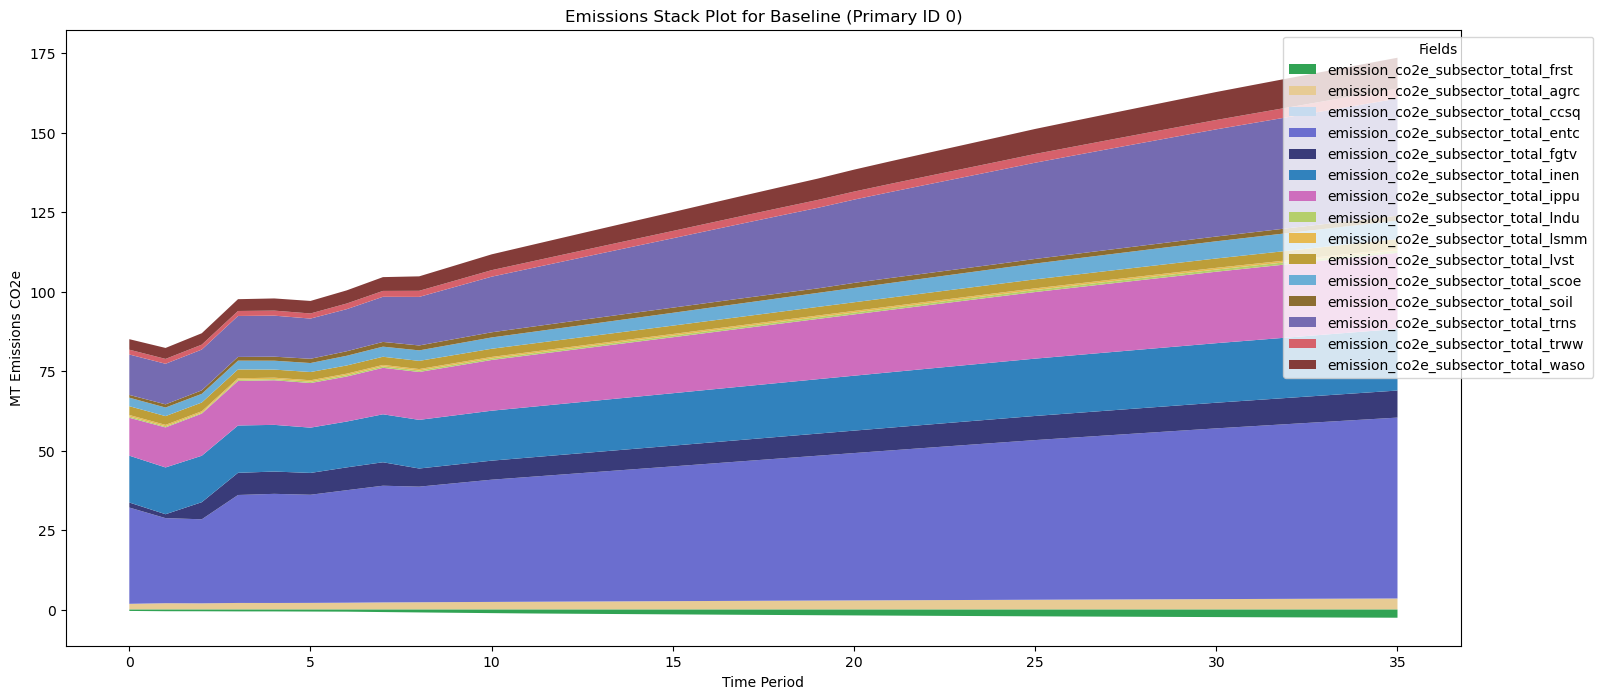

In [46]:
# Plot the emissions stack for the primary_id 0 (which is the baseline)
plot_field_stack(
    df_out,
    subsector_emission_fields,
    dict_format,
    primary_id=0,
    title="Emissions Stack Plot for Baseline (Primary ID 0)"
)

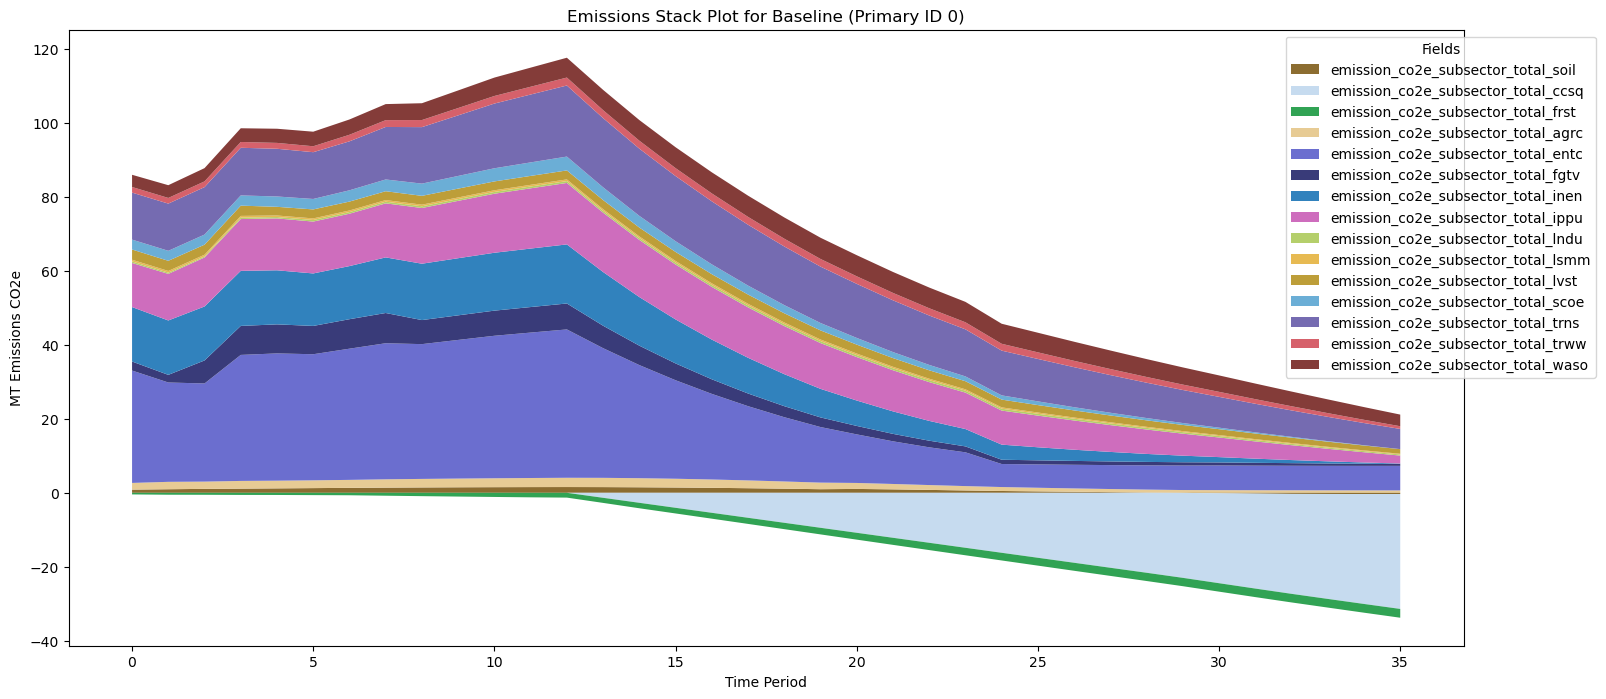

In [ ]:
# Plot the emissions stack for the primary_id 68068 (which is the NetZero scenario)
plot_field_stack(
    df_out,
    subsector_emission_fields,
    dict_format,
    primary_id=68068,
    title="Emissions Stack Plot for NetZero Scenario (Primary ID 68068)"
)

# Export Wide File (Last Mandatory Step)

In [30]:
all_primaries = sorted(list(df_out[ssp.key_primary].unique()))

# build if unable to simply read the data frame
if df_in is None:
    df_in = []
     
    for region in ssp.regions:
        for primary in all_primaries: 
            df_in_filt = ssp.generate_scenario_database_from_primary_key(primary)
            df_in.append(df_in_filt.get(region))
    
    df_in = pd.concat(df_in, axis = 0).reset_index(drop = True)




df_export = pd.merge(
    df_out,
    df_in,
    how = "left",
)



# check output directory 
dir_pkg = os.path.join(
    ssp.file_struct.dir_out, 
    f"sisepuede_summary_results_run_{ssp.id_fs_safe}"
)
os.makedirs(dir_pkg) if not os.path.exists(dir_pkg) else None


for tab in ["ATTRIBUTE_STRATEGY"]:
    table_df = ssp.database.db.read_table(tab)
    if table_df is not None:
        table_df.to_csv(
            os.path.join(dir_pkg, f"{tab}.csv"),
            index=None,
            encoding="UTF-8"
        )
    else:
        print(f"Warning: Table {tab} returned None.")


df_primary = (
    ssp
    .odpt_primary
    .get_indexing_dataframe(
        sorted(list(df_out[ssp.key_primary].unique()))
    )
)
    
df_primary.to_csv(
    os.path.join(dir_pkg, f"ATTRIBUTE_PRIMARY.csv"),
    index = None,
    encoding = "UTF-8"
)

df_export.to_csv(
    os.path.join(dir_pkg, f"sisepuede_results_{ssp.id_fs_safe}_WIDE_INPUTS_OUTPUTS.csv"),
    index = None,
    encoding = "UTF-8"
)

In [31]:
# Getting the directory where the outputs are stored
ssp.file_struct.dir_out

'/Users/fabianfuentes/anaconda3/envs/ssp_libya_env/lib/python3.11/site-packages/sisepuede/out'

In [32]:
RUN_ID_OUTPUT_DIR_PATH = os.path.join(
    RUN_OUTPUT_DIR_PATH, 
    f"sisepuede_results_run_{ssp.id_fs_safe}"
)

os.makedirs(RUN_ID_OUTPUT_DIR_PATH, exist_ok=True)

df_primary.to_csv(
    os.path.join(RUN_ID_OUTPUT_DIR_PATH, "ATTRIBUTE_PRIMARY.csv"),
    index = None,
    encoding = "UTF-8"
)

df_export.to_csv(
    os.path.join(RUN_ID_OUTPUT_DIR_PATH, f"sisepuede_results_{ssp.id_fs_safe}_WIDE_INPUTS_OUTPUTS.csv"),
    index = None,
    encoding = "UTF-8"
)

for tab in ["ATTRIBUTE_STRATEGY"]:
    table_df = ssp.database.db.read_table(tab)
    if table_df is not None:
        table_df.to_csv(
            os.path.join(RUN_ID_OUTPUT_DIR_PATH, f"{tab}.csv"),
            index=None,
            encoding="UTF-8"
        )
    else:
        print(f"Warning: Table {tab} returned None.")